# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import f_oneway

In [ ]:
df=pd.read_csv("cleaned_housing.csv")

In [ ]:
target = "median_house_value"

X = df.drop(target, axis=1)
y = df[target]


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (16512, 12)
Testing shape: (4128, 12)


In [ ]:
# Create Linear regression model
model = LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Model Evaluation

In [ ]:
# R² Score
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R² Score:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

R² Score: 0.6254240620553614
MSE: 4908476721.156606
RMSE: 70060.5218447351


# Visualization

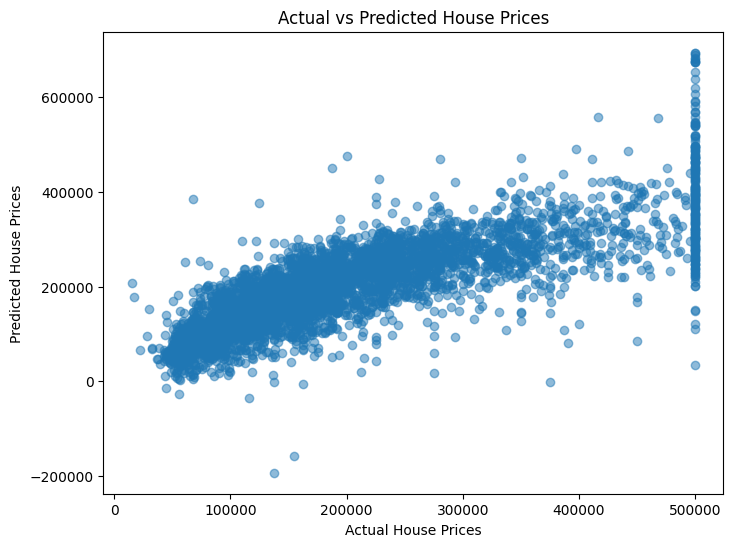

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

# One-way ANOVA

In [ ]:
df_anova = pd.read_csv("housing.csv")
df_anova["total_bedrooms"].fillna(df_anova["total_bedrooms"].median(), inplace=True)

group1 = df_anova[df_anova["ocean_proximity"] == "<1H OCEAN"]["median_house_value"]
group2 = df_anova[df_anova["ocean_proximity"] == "INLAND"]["median_house_value"]
group3 = df_anova[df_anova["ocean_proximity"] == "NEAR OCEAN"]["median_house_value"]
group4 = df_anova[df_anova["ocean_proximity"] == "NEAR BAY"]["median_house_value"]

f_stat, p_value = f_oneway(group1, group2, group3, group4)

print("ANOVA F-Statistic:", f_stat)
print("ANOVA p-value:", p_value)

if p_value < 0.05:
    print("Result: Reject null hypothesis (house prices differ significantly by ocean proximity)")
else:
    print("Result: Fail to reject null hypothesis")

ANOVA F-Statistic: 2144.421030360983
ANOVA p-value: 0.0
Result: Reject null hypothesis (house prices differ significantly by ocean proximity)


/tmp/ipykernel_7087/2828933834.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_anova["total_bedrooms"].fillna(df_anova["total_bedrooms"].median(), inplace=True)


# Residual Plot

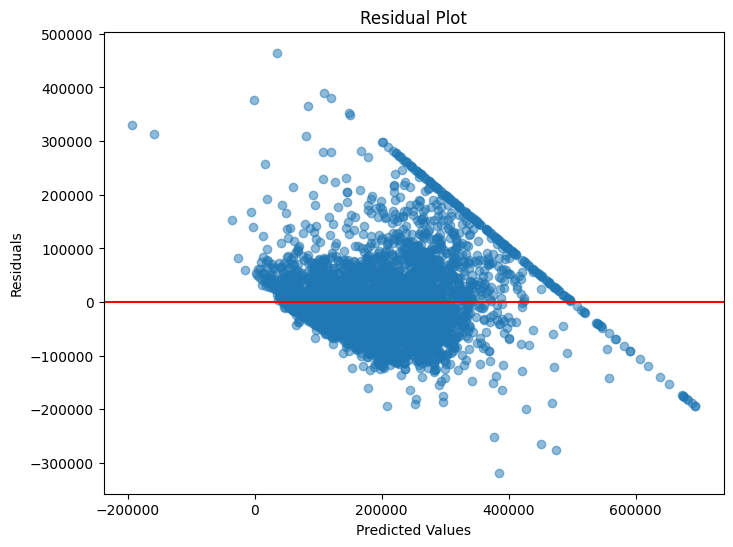

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

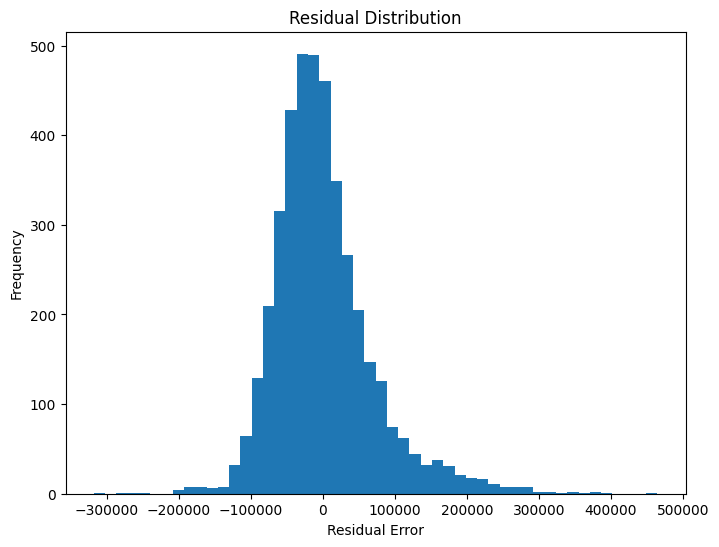

In [ ]:
# Residual Distribution
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=50)
plt.xlabel("Residual Error")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

# Coefficient Analysis

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients.sort_values(by="Coefficient", ascending=False))


                       Feature    Coefficient
9       ocean_proximity_ISLAND  136125.072615
7                median_income   39473.975175
11  ocean_proximity_NEAR OCEAN    3431.140073
2           housing_median_age    1102.185084
4               total_bedrooms     102.789395
6                   households      48.252753
3                  total_rooms      -6.021506
5                   population     -38.172906
10    ocean_proximity_NEAR BAY   -5136.642217
1                     latitude  -25468.352050
0                    longitude  -26838.273372
8       ocean_proximity_INLAND  -39786.656161


# Model Interpretation

In [ ]:
print("""
MODEL INTERPRETATION:

- Positive coefficient → increases house price
- Negative coefficient → decreases house price

Most important feature is usually median_income.
""")



MODEL INTERPRETATION:

- Positive coefficient → increases house price
- Negative coefficient → decreases house price

Most important feature is usually median_income.



# Final Summary

In [ ]:
print("""
WEEK 5 COMPLETED:

✔ Linear Regression model trained
✔ Predictions generated
✔ R² and MSE calculated
✔ Actual vs Predicted plot created
✔ Residual analysis done
✔ Feature importance analyzed
""")


WEEK 5 COMPLETED:

✔ Linear Regression model trained
✔ Predictions generated
✔ R² and MSE calculated
✔ Actual vs Predicted plot created
✔ Residual analysis done
✔ Feature importance analyzed

